# A-RoF CMP-DPD - Hyperparameters optimization with Optuna

In [1]:
import sys

project_path = r"C:\Users\PC\Documents\Mestrado\DPD"
file_path    = project_path + r"\Optuna_studies\DPD_CMP"

sys.path.append(project_path)
sys.path.append(file_path)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import optuna

from scipy.signal             import welch, firwin, hilbert
from scipy.constants          import pi
from tqdm.notebook            import tqdm
from tabulate                 import tabulate
from functools                import partial

from optic.comm.ofdm          import modulateOFDM, demodulateOFDM
from optic.comm.modulation    import modulateGray
from optic.models.channels    import linearFiberChannel
from optic.models.devices     import mzm, photodiode
from optic.comm.metrics       import fastBERcalc, calcEVM
from optic.dsp.core           import pnorm, signal_power, upsample, pulseShape, decimate, finddelay
from optic.dsp.coreGPU        import firFilter
from optic.utils              import parameters, dBm2W
from optic_private.dsp.core   import calcACLR
from optic_private.torchUtils import fitFilterNN

from dpd.mp                   import LS_CMP_solver
from dpd.utils                import power_amplifier
from dpd.plots                import calc_per_carrier
from dpd.optuna_tasks         import objective_dpd, get_pareto

from optuna.trial             import TrialState
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [3]:
font = {'size':14}
plt.rc('font', **font)
plt.rcParams["font.family"] = "serif"

### 1 - Geração do Sinal OFDM

In [4]:
# Parâmetros de modulação
Rb = 5e9                               # Taxa de transmissão de bits
SpS = 32                               # Amostras por símbolo

# Parâmetros OFDM
paramOFDM = parameters()
paramOFDM.modOrder = 64                # Ordem da modulação
paramOFDM.modType  = 'qam'             # Tipo de modulação
paramOFDM.Nfft = 1024                  # Tam. da FFT
paramOFDM.G    = 32                   # Tam. do prefixo cíclico
paramOFDM.hermitSymmetry = False
paramOFDM.SpS = SpS

if paramOFDM.hermitSymmetry:
    Ns = paramOFDM.Nfft//2 - 1
    paramOFDM.pilotCarriers = np.linspace(0, Ns - 1, 8, dtype = np.int64)
    paramOFDM.nullCarriers  = np.array([], dtype = np.int64)
else:
    Ns = paramOFDM.Nfft
    paramOFDM.pilotCarriers = np.linspace(0, Ns - 1, 8, dtype = np.int64)
    paramOFDM.nullCarriers  = np.array([paramOFDM.Nfft//2], dtype = np.int64)

# Núm. de subportadoras de informação
Np = paramOFDM.pilotCarriers.size
Nz = paramOFDM.nullCarriers.size
Ni = Ns - Np - Nz
paramOFDM.Ni = Ni

Rs = Rb / ( Ni/(paramOFDM.Nfft + paramOFDM.G) * np.log2(paramOFDM.modOrder) )    # Taxa de transmissão de símbolos
Fs  = Rs * SpS                                                          # Taxa de amostragem

# Geração dos bits e dos símbolos QAM
numOFDMframes = 50
np.random.seed(2)
bits = np.random.randint(2, size = (numOFDMframes*Ni, int(np.log2(paramOFDM.modOrder))))

symbTx = modulateGray(bits, paramOFDM.modOrder, paramOFDM.modType)
symbTx = pnorm(symbTx)

pilotSymb = 0.25*(max(symbTx.real) + 1j*max(symbTx.imag))
paramOFDM.pilot = pilotSymb

In [5]:
sigTx = modulateOFDM(symbTx, paramOFDM)
sigTx = pnorm(sigTx)

t = np.arange(0, len(sigTx))*1/Fs
t_CP   = SpS * paramOFDM.G * (1/Fs)
t_symb = SpS * (paramOFDM.Nfft + paramOFDM.G) * (1/Fs)

In [6]:
table = [['Grandeza', 'Parâmetro', 'Valor'],
         ['Taxa de amostragem', 'Fs', f'{Fs*1e-9:.2f} Gsamples/s'],
         ['Taxa de símbolos', 'Rs', f'{Rs*1e-9:.2f} Gsymb/s'],
         ['Taxa de transmissão', 'Rb', f'{Rb*1e-9:.2f} Gb/s'],
         ['Ordem da constelação', 'M', f'{paramOFDM.modOrder}'],
         ['Tamanho da FFT', 'Nfft', f'{paramOFDM.Nfft}'],
         ['Tamanho do prefixo cíclico', 'G', f'{paramOFDM.G}'],
         ['Num. port. de informação', 'Ns', f'{Ni}'],
         ['Num. port. piloto', 'Np', f'{Np}'],
         ['Num. port. nulas', 'Nz', f'{Nz}'],
         ['Espaçamento entre subportadoras', 'Delta_f', f'{(Rs/paramOFDM.Nfft)*1e-6:.2f} MHz'],
         ['Duração do símbolo OFDM', 'T_symb', f'{1e9*t_symb:.2f} ns'],
         ['Duração do prefixo cíclico', 'T_CP', f'{1e9*t_CP:.2f} ns'] ]

print(tabulate(table, headers = 'firstrow', tablefmt = 'fancy_grid'))

╒═════════════════════════════════╤═════════════╤══════════════════╕
│ Grandeza                        │ Parâmetro   │ Valor            │
╞═════════════════════════════════╪═════════════╪══════════════════╡
│ Taxa de amostragem              │ Fs          │ 27.74 Gsamples/s │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Taxa de símbolos                │ Rs          │ 0.87 Gsymb/s     │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Taxa de transmissão             │ Rb          │ 5.00 Gb/s        │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Ordem da constelação            │ M           │ 64               │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Tamanho da FFT                  │ Nfft        │ 1024             │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Tamanho do prefixo cíclico      │ G           │ 32               │
├─────────────────────────────────

In [7]:
## Parametrização dos dispositivos

# Parâmetros do MZM
paramMZM = parameters()
paramMZM.Vpi = 3
paramMZM.Vb = -paramMZM.Vpi/2
paramMZM.Pin_OF = 10

# Parâmetros do canal óptico
paramChannel = parameters()
paramChannel.L = 25
paramChannel.alpha = 0.2
paramChannel.D = 16
paramChannel.Fc = 193.1e12
paramChannel.Fs = Fs

#
paramRF = parameters()
paramRF.fc_e = 7.5e9
paramRF.Pin_RF = 17
paramRF.Pin_PA = 5

# Parâmetros do fotodiodo
paramPD = parameters()
paramPD.ideal = False
paramPD.B = paramRF.fc_e + 2*Rs
paramPD.Ipd_sat = 50e-3
paramPD.Fs = Fs

### 2 Canal RoF

In [8]:
# Sinal RF
sigTx_RF = np.real( sigTx * np.exp(1j*2*pi*paramRF.fc_e*t) )

gain_pre_MZM = 10**( np.log10(dBm2W(paramRF.Pin_RF)/signal_power(sigTx_RF))/2)
sigTx_RF *= gain_pre_MZM
sigTx_RF = np.clip(sigTx_RF, -paramMZM.Vpi/2, paramMZM.Vpi/2)

# Sinal óptico
Ai     = np.sqrt(dBm2W(paramMZM.Pin_OF))*np.ones(sigTx_RF.size)
sigTxo = mzm(Ai, sigTx_RF, paramMZM)

numtaps = 4096
hopt_tx = firwin(numtaps, paramRF.fc_e + 2*Rs, fs = Fs)
sigTxo = np.sqrt(signal_power(sigTxo))*pnorm(firFilter(hopt_tx, sigTxo))

sigRxo = linearFiberChannel(sigTxo, paramChannel)

# Sinal elétrico (fotocorrente)
I_Rx = photodiode(sigRxo, paramPD)
I_Rx -= I_Rx.mean()

# Sinal elétrico pós-FPF
numtaps = 4096
f1 = paramRF.fc_e - 2*Rs
f2 = paramRF.fc_e + 2*Rs
hbp_RF = firwin(numtaps, (f1, f2), pass_zero = 'bandpass', fs = Fs)

I_RF = firFilter(hbp_RF, I_Rx)

# Sina elétrico pós-PA
IQ_imb = 1 # 10**(1 / 10) * np.exp(1j* 5 * pi/180)

sigRx = hilbert(I_RF)*np.exp(-1j*2*pi*paramRF.fc_e*t)
sigRx = sigRx.real + 1j*sigRx.imag * IQ_imb

gain_pre_PA = 10**( np.log10(dBm2W(paramRF.Pin_PA)/signal_power(sigRx))/2)
sigRx *= gain_pre_PA

sigRx = power_amplifier(sigRx)

sigRx_PA = sigRx.copy()
sigRx_PA = pnorm(sigRx_PA)

numtaps = 4096
hlp = firwin(numtaps, Rs/1.75, fs = Fs)
sigRx = firFilter(hlp, sigRx)

delay = finddelay(sigRx, sigTx)
sigRx = np.roll(sigRx, -delay)

rot = np.mean(sigTx/sigRx)
sigRx = rot/np.abs(rot)*sigRx

In [9]:
# Param RoF
paramRoF = parameters()
paramRoF.SpS = SpS
paramRoF.Fs  = Fs
paramRoF.Rs  = Rs
paramRoF.IQ_imb = IQ_imb
paramRoF.G_list = (gain_pre_MZM, gain_pre_PA)
paramRoF.paramMZM = paramMZM
paramRoF.paramChannel = paramChannel
paramRoF.paramRF = paramRF
paramRoF.paramPD = paramPD

### 3 Preparação do conjunto de dados de treinamento

In [10]:
SpS_nn = 4

paramDec = parameters()
paramDec.SpS_in = SpS
paramDec.SpS_out = SpS_nn

hlp = firwin(numtaps, SpS_nn*Rs/2, fs = Fs)

sigRef = decimate(pnorm(firFilter(hlp, sigTx)), paramDec).ravel()
sigIn  = decimate(pnorm(sigRx_PA), paramDec).ravel()

delay = finddelay(sigIn, sigRef)
sigIn = np.roll(sigIn, -delay)

rot = np.mean(sigRef/sigIn)
sigIn = rot/np.abs(rot)*sigIn

### 4 - Arquitetura de Aprendizado Indireto (ILA)

In [11]:
paramILA = parameters()

paramILA.DPD = "CMP"

paramILA.N = 37_500
paramILA.numIter = 5

paramILA.SpS_DPD = 4
paramILA.directLearn = False

In [12]:
attr_test = parameters()
attr_test.symbTx    = symbTx
attr_test.paramRoF  = paramRoF
attr_test.paramOFDM = paramOFDM
attr_test.paramDPD  = paramILA

attr_train = parameters()
attr_train.sigIn  = sigIn
attr_train.sigRef = sigRef
attr_train.paramDPD = paramILA

In [14]:
n_trials  = 500
n_studies = np.array([2])
timeout = 60*60*15
save = True

for i in n_studies:
    objective_ILA = partial(objective_dpd, attr_test = attr_test, attr_train = attr_train, metrics = ["EVM", "NFLOPs"], 
                            model_path = file_path + f"\\ILA\\Study_{i}\\Models")
    
    print(f"Study {i}:")
    study_ILA = optuna.create_study(directions=["minimize", "minimize"], sampler = optuna.samplers.TPESampler())
    study_ILA.optimize(objective_ILA, n_trials = n_trials, timeout = timeout, show_progress_bar = True)
    
    complete_trials   = study_ILA.get_trials(deepcopy = False, states = [TrialState.COMPLETE])
    n_complete_trials = len(complete_trials)
    
    study_P1 = np.zeros(n_complete_trials)
    study_M1 = np.zeros(n_complete_trials)
    study_P2 = np.zeros(n_complete_trials)
    study_M2 = np.zeros(n_complete_trials)
    
    study_EVM    = np.zeros(n_complete_trials)
    #study_ACLR   = np.zeros(n_complete_trials)
    study_NFLOPs = np.zeros(n_complete_trials)
    
    for j in range(n_complete_trials):
        trials_params   = complete_trials[j].params
        study_EVM[j]    = complete_trials[j].values[0]
        #study_ACLR[j]   = complete_trials[j].values[1]
        study_NFLOPs[j] = complete_trials[j].values[1]
        
        study_P1[j] = trials_params["P1"]
        study_M1[j] = trials_params["M1"]
        
        study_P2[j] = trials_params["P2"]
        study_M2[j] = trials_params["M2"]
    
    if save:
        np.savetxt(file_path + f'\\ILA\\Study_{i}\\Parameters\\P1.txt', study_P1, fmt = '%f')
        np.savetxt(file_path + f'\\ILA\\Study_{i}\\Parameters\\M1.txt', study_M1, fmt = '%f')
        np.savetxt(file_path + f'\\ILA\\Study_{i}\\Parameters\\P2.txt', study_P2, fmt = '%f')
        np.savetxt(file_path + f'\\ILA\\Study_{i}\\Parameters\\M2.txt', study_M2, fmt = '%f')
        #np.savetxt(file_path + f'\\ILA\\Study_{i}\\Results\\ACLR.txt', study_ACLR, fmt = '%f')
        np.savetxt(file_path + f'\\ILA\\Study_{i}\\Results\\EVM.txt', study_EVM, fmt = '%f')
        np.savetxt(file_path + f'\\ILA\\Study_{i}\\Results\\NFLOps.txt', study_NFLOPs, fmt = '%f')

Study 2:


  0%|          | 0/500 [00:00<?, ?it/s]

In [15]:
study_ACLR = np.array([ np.loadtxt(file_path + f"\\ILA\\Study_{n_studies[0]}\\Models\\metrics_{i+1}.txt")[1] for i in range(n_trials) ])

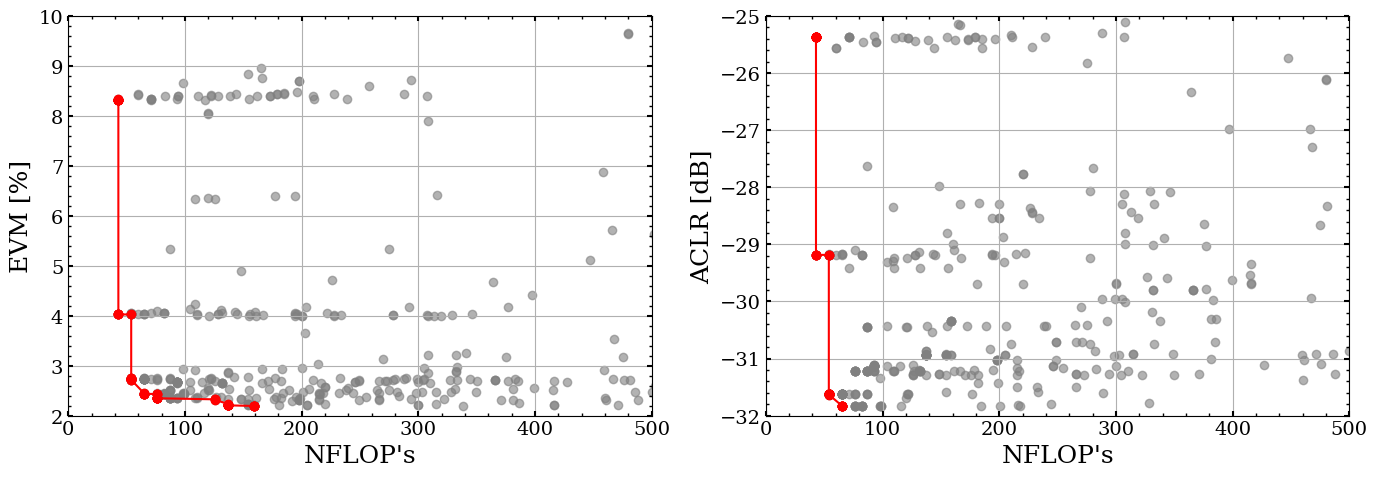

In [19]:
fig, axs = plt.subplots(1, 2, figsize = (14, 5))

# EVM vs NFLOPs
pareto_solutions_evm, pareto_trials_evm = get_pareto(study_EVM, study_NFLOPs, n_trials)

axs[0].scatter(study_NFLOPs, study_EVM, color = "gray", alpha = 0.6)
axs[0].plot(pareto_solutions_evm[:,1], pareto_solutions_evm[:,0], "-o", color = "r")

axs[0].set_xlim(0, 5e2)
axs[0].set_ylim(2., 10)
axs[0].set_xlabel("NFLOP's", fontsize = 18)
axs[0].set_ylabel("EVM [%]", fontsize = 18)

axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[0].grid()

# ACLR vs NFLOPs
pareto_solutions_aclr, pareto_trials_aclr = get_pareto(study_ACLR, study_NFLOPs, n_trials)

axs[1].scatter(study_NFLOPs, study_ACLR, color = "gray", alpha = 0.6)
axs[1].plot(pareto_solutions_aclr[:,1], pareto_solutions_aclr[:,0], "-o", color = "r")

axs[1].set_xlim(0, 5e2)
axs[1].set_ylim(-32, -25)
axs[1].set_xlabel("NFLOP's", fontsize = 18)
axs[1].set_ylabel("ACLR [dB]", fontsize = 18)

axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[1].grid()

plt.tight_layout()
#plt.savefig(file_path + "\\Plots\\plot_pareto_EVM.png")

In [17]:
# Pareto Trials - EVM vs NFLOPs

for i, trial in enumerate(pareto_trials_evm):
    print(f"Trial {trial}: EVM = {study_EVM[trial]:.3f} %, NFLOPs = {study_NFLOPs[trial]}") 

Trial 33: EVM = 8.318 %, NFLOPs = 43.0
Trial 93: EVM = 2.433 %, NFLOPs = 76.0
Trial 111: EVM = 2.314 %, NFLOPs = 126.0
Trial 118: EVM = 8.313 %, NFLOPs = 43.0
Trial 123: EVM = 8.329 %, NFLOPs = 43.0
Trial 158: EVM = 4.025 %, NFLOPs = 54.0
Trial 162: EVM = 8.317 %, NFLOPs = 43.0
Trial 164: EVM = 8.326 %, NFLOPs = 43.0
Trial 172: EVM = 8.323 %, NFLOPs = 43.0
Trial 175: EVM = 8.315 %, NFLOPs = 43.0
Trial 177: EVM = 8.327 %, NFLOPs = 43.0
Trial 229: EVM = 2.215 %, NFLOPs = 137.0
Trial 246: EVM = 8.321 %, NFLOPs = 43.0
Trial 249: EVM = 2.433 %, NFLOPs = 76.0
Trial 267: EVM = 8.314 %, NFLOPs = 43.0
Trial 276: EVM = 8.325 %, NFLOPs = 43.0
Trial 279: EVM = 2.431 %, NFLOPs = 76.0
Trial 280: EVM = 2.325 %, NFLOPs = 126.0
Trial 285: EVM = 2.325 %, NFLOPs = 126.0
Trial 290: EVM = 4.027 %, NFLOPs = 43.0
Trial 300: EVM = 4.026 %, NFLOPs = 43.0
Trial 301: EVM = 4.025 %, NFLOPs = 43.0
Trial 303: EVM = 2.221 %, NFLOPs = 137.0
Trial 304: EVM = 2.211 %, NFLOPs = 137.0
Trial 305: EVM = 2.232 %, NFLOPs = 1

In [18]:
# Pareto Trials - ACLR vs NFLOPs

for i, trial in enumerate(pareto_trials_aclr):
    print(f"Trial {trial}: ACLR = {study_ACLR[trial]:.3f} dB, NFLOPs = {study_NFLOPs[trial]}") 

Trial 33: ACLR = -25.367 dB, NFLOPs = 43.0
Trial 118: ACLR = -25.365 dB, NFLOPs = 43.0
Trial 123: ACLR = -25.368 dB, NFLOPs = 43.0
Trial 154: ACLR = -29.187 dB, NFLOPs = 54.0
Trial 162: ACLR = -25.366 dB, NFLOPs = 43.0
Trial 164: ACLR = -25.366 dB, NFLOPs = 43.0
Trial 172: ACLR = -25.368 dB, NFLOPs = 43.0
Trial 175: ACLR = -25.366 dB, NFLOPs = 43.0
Trial 177: ACLR = -25.366 dB, NFLOPs = 43.0
Trial 201: ACLR = -29.185 dB, NFLOPs = 54.0
Trial 246: ACLR = -25.368 dB, NFLOPs = 43.0
Trial 267: ACLR = -25.369 dB, NFLOPs = 43.0
Trial 276: ACLR = -25.367 dB, NFLOPs = 43.0
Trial 290: ACLR = -29.183 dB, NFLOPs = 43.0
Trial 300: ACLR = -29.184 dB, NFLOPs = 43.0
Trial 301: ACLR = -29.183 dB, NFLOPs = 43.0
Trial 312: ACLR = -31.630 dB, NFLOPs = 54.0
Trial 313: ACLR = -31.825 dB, NFLOPs = 65.0
Trial 314: ACLR = -31.631 dB, NFLOPs = 54.0
Trial 322: ACLR = -31.624 dB, NFLOPs = 54.0
Trial 323: ACLR = -31.626 dB, NFLOPs = 54.0
Trial 324: ACLR = -31.624 dB, NFLOPs = 54.0
Trial 325: ACLR = -31.627 dB, NFL